In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

from scvi.external import ContrastiveVI

sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

## Load data & compute treatment effects

In [3]:
data = slk.datasets.replogle()

In [4]:
perturbations = set(np.unique(data.obs[slk.configs.get_config('pert_key')].values))
print("Perturbations:", len(perturbations))

pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
print("Pathways:", len(pathways))

Perturbations: 682
Pathways: 8


In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect'
)

100%|██████████| 681/681 [00:08<00:00, 79.25it/s]


## Train ContrastiveVI

Architecture (Weinberger et al. 2023):
- **Background encoder** `q(z | x)` — shared variation present in both NTC and perturbed cells
- **Salient encoder** `q(s | x)` — perturbation-specific variation; NTC cells are trained with `s = 0`
- **Decoder** `p(x | z, s)` — reconstructs expression from both latents

Training explicitly separates NTC (*background* group) from perturbed cells (*target* group).
The wrapper `slk.tl.ContrastiveVIWrapper` hooks the trained scvi model into our `PerturbModelBase` pipeline.

In [6]:
p_key     = slk.configs.get_config('pert_key')
ntc_label = slk.configs.get_config('ntc_label')

ContrastiveVI.setup_anndata(data, layer=None)

background_indices = np.where(data.obs[p_key] == ntc_label)[0].tolist()
target_indices     = np.where(data.obs[p_key] != ntc_label)[0].tolist()

print(f"Background (NTC): {len(background_indices):,}  |  Target (perturbed): {len(target_indices):,}")

Background (NTC): 2,000  |  Target (perturbed): 116,641


In [7]:
N_BACKGROUND_LATENT = 10
N_SALIENT_LATENT    = 10

scvi_model = ContrastiveVI(
    data,
    n_hidden=128,
    n_background_latent=N_BACKGROUND_LATENT,
    n_salient_latent=N_SALIENT_LATENT,
    n_layers=1,
    dropout_rate=0.1,
    use_observed_lib_size=True,
    wasserstein_penalty=0,
)

scvi_model.train(
    background_indices=background_indices,
    target_indices=target_indices,
    max_epochs=200,
    batch_size=4096,
    early_stopping=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/envs/perturb/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to impr

Epoch 1/200:   0%|          | 0/200 [00:00<?, ?it/s]

/opt/conda/envs/perturb/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 72. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Epoch 200/200: 100%|██████████| 200/200 [49:15<00:00, 14.33s/it, v_num=1, train_loss_step=3.61e+3, train_loss_epoch=3.54e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [49:15<00:00, 14.78s/it, v_num=1, train_loss_step=3.61e+3, train_loss_epoch=3.54e+3]


## Wrap in PerturbModelBase

`ContrastiveVIWrapper` (defined in `sherlock/tools/_contrastivevi.py`) maps the scvi model onto the
`PerturbModelBase` interface so the standard eval / clustering / counterfactual pipeline works unchanged:

| Hook | ContrastiveVI mapping |
|------|-----------------------|
| `get_z(x, p)` | salient mean `E[q(s\|x)]` — perturbation-specific latent |
| `get_recon(x, p)` | decode from `cat([E[q(z\|x)], E[q(s\|x)]])` |
| `_get_rho_embed` | pseudobulk mean of `s` per perturbation |
| `_abduct_ntc` | background mean `E[q(z\|x_NTC)]` |
| `_get_all_pert_shifts` | per-perturbation mean salient `ŝ_p` (precomputed in `_eval`) |
| `_apply_shift(u, m_p)` | `cat([u, m_p])` — forms full `[z, s]` decoder input |
| `_decode_to_expr` | pads `s=0` for NTC baseline; uses `[z, s]` for CF |

Counterfactuals: abduct background `z` from NTC → K-means centroids → decode `f(z_k, ŝ_p)` vs `f(z_k, 0)`.

In [8]:
wrapper = slk.tl.ContrastiveVIWrapper(
    scvi_model=scvi_model,
    n_background_latent=N_BACKGROUND_LATENT,
    n_salient_latent=N_SALIENT_LATENT,
)

## Save & load

ContrastiveVI uses scvi's native save/load; the wrapper is re-created around the loaded model.

In [9]:
os.makedirs('../results', exist_ok=True)
scvi_model.save('../results/contrastivevi_model/', overwrite=True)

In [12]:
scvi_model_loaded = ContrastiveVI.load('../results/contrastivevi_model/', adata=data)
wrapper = slk.tl.ContrastiveVIWrapper(
    scvi_model=scvi_model_loaded,
    n_background_latent=N_BACKGROUND_LATENT,
    n_salient_latent=N_SALIENT_LATENT,
)

INFO     File ../results/contrastivevi_model/model.pt already downloaded                                           


## Evaluate

`z` stores the **salient** latent `s = E[q(s|x)]` per cell — the perturbation-specific representation.  
`rho_corr` is the Pearson correlation of pseudobulk mean salient vectors `ŝ_p` across perturbations.  
Because ContrastiveVI has no explicit shift vectors, `rho_corr == z_corr` (both use pseudobulk mean of `s`).

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
slk.tl.eval_single(wrapper, data, obsm_key="z", uns_key="results")
data.uns['results'].keys()

dict_keys(['z_corr', 'perts', 'rho_corr', 'rho_perts', 'rho_embed'])

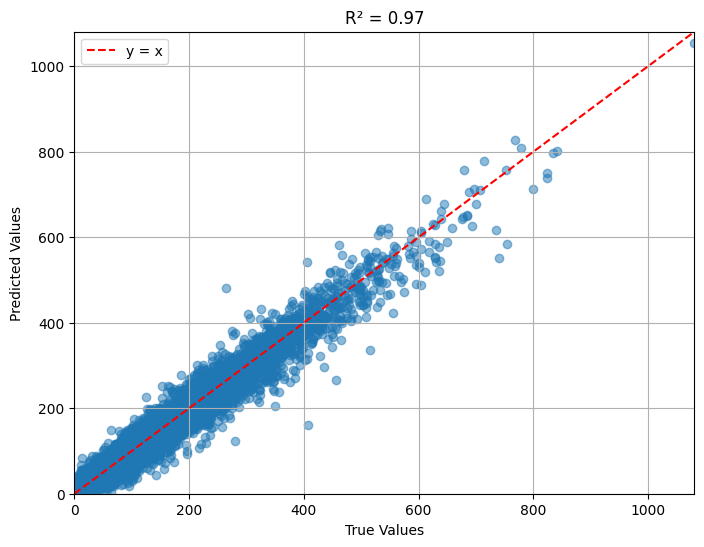

In [15]:
slk.pl.plot_r2(data)

## UMAP of salient latent z (= s)

Each point is a perturbed cell. The salient latent `s` should capture variation specific to each perturbation.

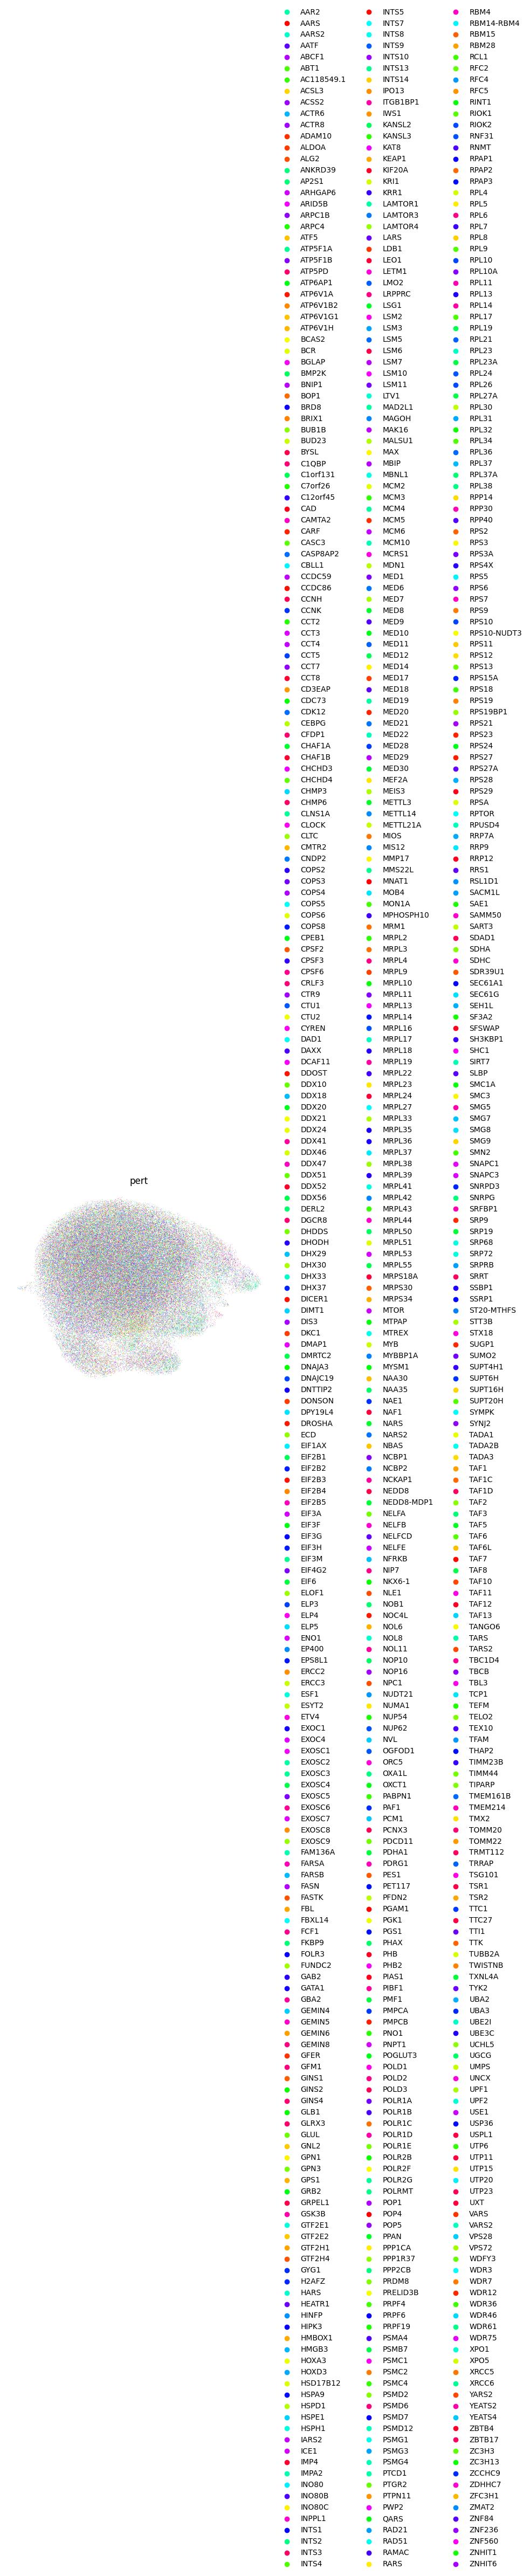

In [30]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

## Perturbation embedding correlation (rho_corr)

`rho_corr` is computed from pseudobulk mean salient vectors `ŝ_p` — the model's perturbation similarity.

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


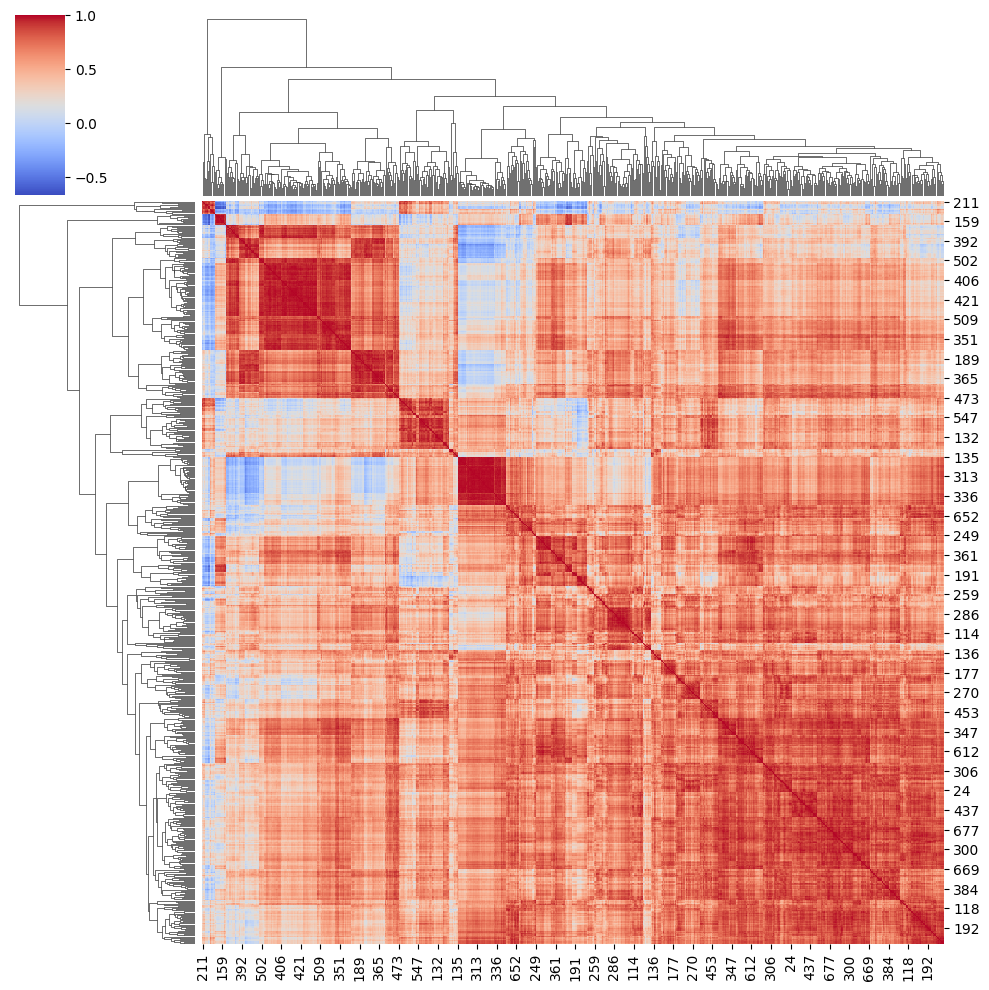

In [16]:
slk.pl.plot_corr(data)

## ATE — counterfactual effect prediction

Uses base class `predict_counterfactual_effects`:
- Abducts background `z` from NTC cells  
- K-means centroids in z-space  
- Decodes `f(z_k, ŝ_p)` vs `f(z_k, 0)` (NTC baseline has `s = 0`)  
- Predicted ATE per perturbation × gene is the difference in log-normalised counts

In [17]:
ate = wrapper.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
)
print("Pearson r (predicted vs observed ATE):", ate['corr'])

Pearson r (predicted vs observed ATE): 0.5523371696472168


## z_corr vs rho_corr consistency

For ContrastiveVI, both are computed from pseudobulk mean salient `s`, so they should be identical (r ≈ 1).

In [18]:
z_corr   = data.uns['results'].get('z_corr')
rho_corr = data.uns['results'].get('rho_corr')

from scipy.stats import pearsonr, spearmanr

pearson  = pearsonr(z_corr.flatten(),  rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())

print(f"Spearman ρ = {spearman[0]:.3f}  (p = {spearman[1]:.1e})")
print(f" Pearson  r = {pearson[0]:.3f}  (p = {pearson[1]:.1e})")

Spearman ρ = 1.000  (p = 0.0e+00)
 Pearson  r = 1.000  (p = 0.0e+00)


## Replogle pathway clustering

Subset `rho_corr` (correlation of `ŝ_p` vectors) to pathway genes, then cluster.

In [19]:
rho_perts = data.uns['results']['rho_perts']
print(f"rho_corr shape: {rho_corr.shape}, perts: {len(rho_perts)}")

rho_corr shape: (681, 681), perts: 681


In [20]:
C = rho_corr

In [21]:
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

rho_perts_list = list(rho_perts)
gene_ids = [rho_perts_list.index(g) for g in all_genes if g in rho_perts_list]
pathway_genes_found = [g for g in all_genes if g in rho_perts_list]

print(f"Found {len(pathway_genes_found)} / {len(all_genes)} pathway genes in rho_perts")
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

Found 335 / 335 pathway genes in rho_perts


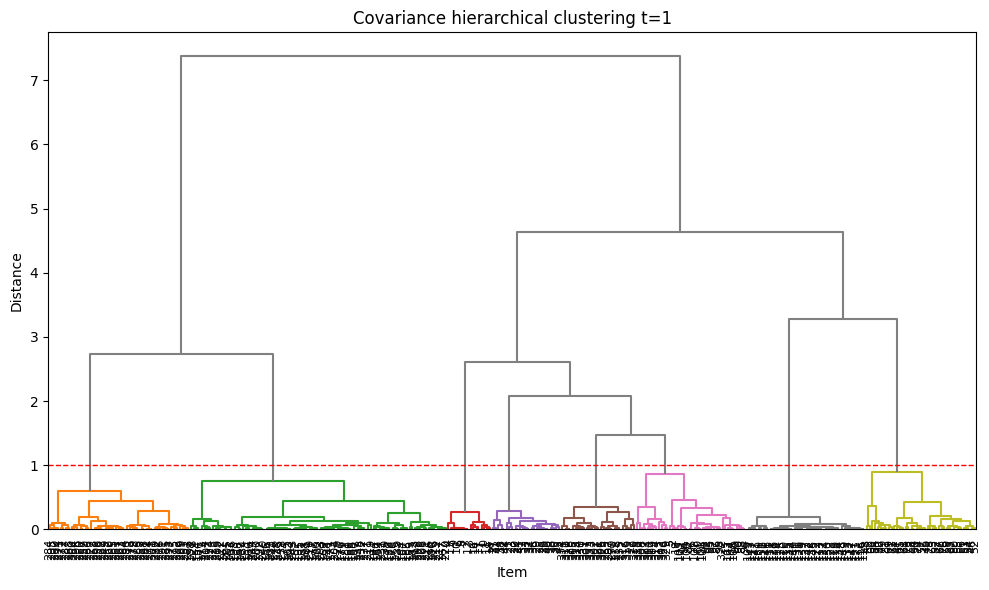

In [23]:
groups = slk.tl.cluster_rho(data, t=1, rho_corr=cov_subset, show=True)

In [24]:
named_groups = slk.tl.group2name(groups, pathway_genes_found)
named_groups

,group
ZC3H3,3
ZFC3H1,3
CAMTA2,6
DHX29,3
DIS3,3
...,...
SNRPG,5
TIPARP,5
TTC27,6
TXNL4A,5


## Clustering metrics vs ground-truth pathways

In [25]:
from collections import Counter

gene_counts  = Counter(pathway_genes_found)
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]
if shared_genes:
    print(f"⚠️  {len(shared_genes)} genes shared across pathways: {shared_genes[:10]}")
else:
    print("✅ Each gene appears in exactly one pathway.")

perts_df = pd.DataFrame(groups, index=pathway_genes_found, columns=['cluster'])

gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes
    if gene in rho_perts_list
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient='index', columns=['cluster'])

perts_df   = perts_df.drop(shared_genes, errors='ignore')
pathway_df = pathway_df.drop(shared_genes, errors='ignore')

print(f"perts_df: {perts_df.shape}  |  pathway_df: {pathway_df.shape}")

✅ Each gene appears in exactly one pathway.
perts_df: (335, 1)  |  pathway_df: (335, 1)


In [26]:
pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']

perts_aligned = perts_df.loc[pathway_df.index].copy()
perts_aligned['gene'] = perts_aligned.index.copy()

In [27]:
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure, silhouette_score,
    precision_score, recall_score, f1_score,
)
from scipy.optimize import linear_sum_assignment


def align_and_summarize(
    clusters_df, pathways_df,
    gene_col='gene', cluster_col='cluster', pathway_col='pathway',
    min_pathway_size=1, gene_embeddings=None,
):
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col, how='inner', validate='one_to_one'
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    if min_pathway_size > 1:
        keep = df[pathway_col].value_counts()
        df = df[df[pathway_col].isin(keep[keep >= min_pathway_size].index)].copy()

    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}
    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    mapped   = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy  = float(is_match.mean())
    precision = precision_score(y_true, mapped, average='macro', zero_division=0)
    recall    = recall_score(y_true, mapped, average='macro', zero_division=0)
    f1        = f1_score(y_true, mapped, average='macro', zero_division=0)
    ari       = adjusted_rand_score(y_true, y_pred)
    ami       = adjusted_mutual_info_score(y_true, y_pred)
    hom, comp, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

    sil = None
    if gene_embeddings is not None:
        emb = gene_embeddings.loc[df[gene_col].values].values
        sil = silhouette_score(emb, mapped, metric='euclidean')

    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority    = g[pathway_col].mode().iat[0]
        purity      = (g[pathway_col] == majority).mean()
        pathway_tot = (df[pathway_col] == majority).sum()
        recall_cl   = (g[pathway_col] == majority).sum() / pathway_tot
        purity_rows.append({'cluster': str(cl), 'size': len(g),
                            'mapped_pathway': mapping.get(str(cl)),
                            'purity': purity, 'recall': recall_cl})
    purity_df = pd.DataFrame(purity_rows).sort_values('cluster').set_index('cluster')

    df['mapped_pathway'] = mapped
    df['is_match']       = is_match

    return {
        'merged': df[[gene_col, cluster_col, pathway_col, 'mapped_pathway', 'is_match']].rename(
            columns={gene_col: 'gene', cluster_col: 'cluster', pathway_col: 'pathway'}),
        'mapping': mapping, 'accuracy': accuracy,
        'precision': precision, 'recall': recall, 'f1': f1,
        'ari': ari, 'ami': ami,
        'homogeneity': hom, 'completeness': comp, 'v_measure': vmeas,
        'silhouette': sil,
        'purity_df': purity_df,
        'contingency': contingency_df,
    }

In [28]:
# Gene embeddings for silhouette: pseudobulk mean salient from rho_embed
rho_embed = data.uns['results']['rho_embed']   # (P_non_ntc, salient_dim)
gene_embeddings = pd.DataFrame(rho_embed, index=list(rho_perts))
gene_embeddings = gene_embeddings.loc[
    gene_embeddings.index.intersection(perts_aligned.index)
]

cluster_results = align_and_summarize(
    clusters_df=perts_aligned,
    pathways_df=pathway_df,
    gene_col='gene',
    cluster_col='cluster',
    pathway_col='pathway',
    min_pathway_size=1,
    gene_embeddings=gene_embeddings,
)

print("Best cluster→pathway mapping:")
for cl, pw in cluster_results['mapping'].items():
    print(f"  {cl} → {pw}")

print(f"\nAccuracy:    {cluster_results['accuracy']:.3f}")
print(f"Precision:   {cluster_results['precision']:.3f}  Recall: {cluster_results['recall']:.3f}  F1: {cluster_results['f1']:.3f}")
print(f"ARI: {cluster_results['ari']:.3f}  AMI: {cluster_results['ami']:.3f}")
print(f"Homogeneity: {cluster_results['homogeneity']:.3f}  Completeness: {cluster_results['completeness']:.3f}  V-measure: {cluster_results['v_measure']:.3f}")
if cluster_results['silhouette'] is not None:
    print(f"Silhouette:  {cluster_results['silhouette']:.3f}")
print("\nPer-cluster purity:")
print(cluster_results['purity_df'])

Best cluster→pathway mapping:
  3 → EXOSOME
  4 → MEDIATOR_COMPLEX
  8 → MT_PROTEIN_TRANSLOCATION
  6 → NUCLEOTIDE_EXCISION_REPAIR
  7 → S39_RIBOSOMAL_UNIT
  2 → S40_RIBOSOMAL_UNIT
  1 → S60_RIBOSOMAL_UNIT
  5 → SPLICEOSOME

Accuracy:    0.925
Precision:   0.912  Recall: 0.909  F1: 0.901
ARI: 0.898  AMI: 0.896
Homogeneity: 0.902  Completeness: 0.898  V-measure: 0.900
Silhouette:  0.404

Per-cluster purity:
         size              mapped_pathway    purity    recall
cluster                                                      
1          51          S60_RIBOSOMAL_UNIT  0.980392  0.943396
2          93          S40_RIBOSOMAL_UNIT  1.000000  0.958763
3          16                     EXOSOME  1.000000  0.800000
4          25            MEDIATOR_COMPLEX  1.000000  0.961538
5          27                 SPLICEOSOME  0.740741  0.606061
6          40  NUCLEOTIDE_EXCISION_REPAIR  0.575000  1.000000
7          43          S39_RIBOSOMAL_UNIT  1.000000  1.000000
8          40    MT_PROTEIN_TRAN

## UMAP coloured by true pathway vs predicted cluster

/var/tmp/ipykernel_3205797/1426620886.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_cats))


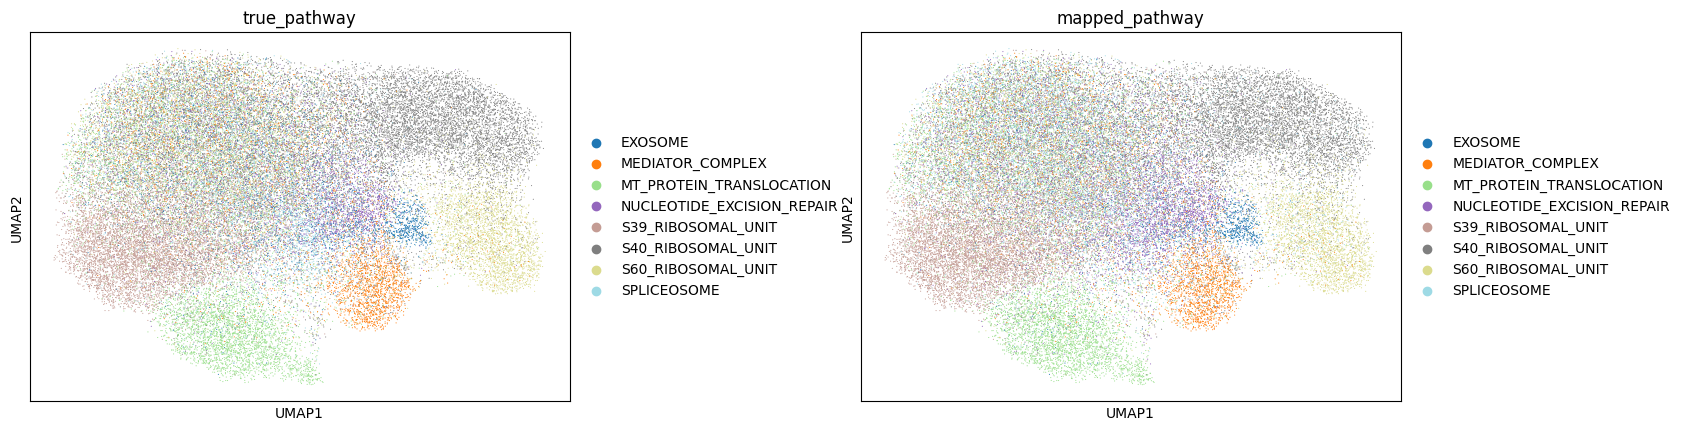

In [31]:
results_df = cluster_results['merged']
clustered_genes = results_df['gene'].unique()

z_sub = sub[sub.obs['pert'].isin(clustered_genes)].copy()
sc.pp.neighbors(z_sub, use_rep='z')
sc.tl.umap(z_sub)

from matplotlib.colors import to_hex

gene_to_true   = dict(zip(results_df['gene'], results_df['pathway']))
gene_to_mapped = dict(zip(results_df['gene'], results_df['mapped_pathway']))

z_sub.obs['true_pathway']   = z_sub.obs['pert'].map(gene_to_true)
z_sub.obs['mapped_pathway'] = z_sub.obs['pert'].map(gene_to_mapped)
z_sub = z_sub[z_sub.obs['mapped_pathway'].notna() & (z_sub.obs['mapped_pathway'] != 'NA')].copy()

all_cats  = pd.Index(np.unique(
    list(z_sub.obs['true_pathway'].dropna().unique()) +
    list(z_sub.obs['mapped_pathway'].dropna().unique())
))
cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

cmap = plt.cm.get_cmap('tab20', len(all_cats))
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}
z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in all_cats]
z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in all_cats]

sc.pl.umap(z_sub, color=['true_pathway', 'mapped_pathway'], wspace=0.4)